# Image generation for 2 phase of the challenge

## Phase 2: setup and challenge data

This notebook prepares the Phase 2 dataset, imports the required libraries, and initializes the modeling workflow used for evaluation. It also defines the color palette and plotting settings used throughout the visualizations.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib as mpl  

from sklearn.decomposition import PCA, TruncatedSVD
from catboost import CatBoostClassifier
from sklearn.metrics import (
        average_precision_score, precision_recall_curve,
        matthews_corrcoef, accuracy_score, roc_auc_score
        )

c_map = {'MediBoost': '#01b4dd',
        'SiraćHC': '#f29042',
        'ZMF': '#d83187',
        'IMPERIA': '#24195c',
        'Kronos': '#212529',
        'Baseline': '#bab9bb',
        'ATMC': '#e31a1c',
        'LHMS 1': '#fffc00',
        'Artificial Innovators': '#228b22',
        'irb-red': '#d92725',
        'irb-blue': '#22458b',
        'irb-gray': '#bab9bb',
        'Challengers': '#988fca',}
cmap = c_map
FONTSIZE = 36
FONTNAME = 'Arial'
MARKERSCALE = 4
FIGSIZE= (14, 14)
mpl.rc('font',family=FONTNAME)

## Baseline model and label check

The challenge baseline is loaded together with the Phase 2 dataset to inspect the class distribution and confirm the evaluation setup. This step verifies that the target labels and out-of-distribution splits are consistent before model comparison.

In [2]:
from baseline_phase2 import Dataset, MLModel

D = Dataset()
D.load_data()
D.Label.value_counts(normalize=True)
model = MLModel(CatBoostClassifier(), D)

## Bootstrap-based performance estimation

This section defines the bootstrap cross-validation procedure used to estimate model performance on both in-distribution and out-of-distribution samples. The method resamples the test set repeatedly to reduce sensitivity to a single split and capture variability in the metric estimates.

In [3]:
def get_leftover_samples(predictions, y_proba, y_test,  k =0):
    yhat = pd.DataFrame(predictions, columns=['pred_Label'])
    y_pro = pd.DataFrame(y_proba, columns=['pred_proba'])
    y_test = pd.DataFrame(y_test, columns=['true_Label'])
    df = pd.concat([yhat, y_test, y_pro], axis=1)
    negative = df[df.true_Label == 0]
    positive = df[df.true_Label == 1]    

    number_negative = negative.shape[0]
    number_positive = positive.shape[0]
    negative_sampled = negative.sample(number_negative, replace=True, random_state=k)
    leftover_negative_samples = negative[~negative.index.isin(negative_sampled.index)]
    positive_sampled = positive.sample(number_positive, replace=True, random_state= k)
    leftover_positive_samples = positive[~positive.index.isin(positive_sampled.index)]
    df = pd.concat([leftover_negative_samples, leftover_positive_samples], axis=0)
    # print(df.shape, df.columns)
    return df.pred_Label.values, df.true_Label.values, df.pred_proba.values

def BBC_CV(sample_size, predictions, y_proba, 
            num_bootstraps_BBC_CV, ytest, eval):
    out_samples_performances = np.zeros(num_bootstraps_BBC_CV)
    roc_auc_performances = np.zeros(num_bootstraps_BBC_CV)
    # boot_out = np.zeros(num_bootstraps_BBC_CV)
    # print(y_proba.shape, predictions.shape, ytest.shape)
    for current_bootstrap in range(num_bootstraps_BBC_CV):
        pred, y_out_samples, y_pr = get_leftover_samples(
            predictions, y_proba, ytest, current_bootstrap)        
        out_samples_perf = eval(
            pred, y_out_samples)
        # print(y_pr.shape)
        roc_auc_perf = roc_auc_score(y_out_samples,y_pr)
        out_samples_performances[current_bootstrap] = out_samples_perf
        roc_auc_performances[current_bootstrap] = roc_auc_perf
        if current_bootstrap % 1000 == 0:
            print(f"Bootstrap {current_bootstrap} done")
    corrected_performance = np.mean(out_samples_performances)
    return corrected_performance, out_samples_performances, roc_auc_performances


Each team submission is evaluated using the bootstrap procedure to estimate the distribution of MCC scores under both normal and shifted data conditions. This allows a more robust comparison of model stability than a single point estimate.

In [4]:
def bootstrapped_model_evaluation(eval = matthews_corrcoef):
    list_dir = os.listdir('task1_phase2')
    df = pd.DataFrame([])
    df_roc = pd.DataFrame([])
    for d in list_dir:
        if '.csv' in d:
            pred = pd.read_csv(f'task1_phase2/{d}')
            pred_np = pred['Label'].values
            proba_np = pred['Probability_1'].values
            ypred = pred_np[-len(model.ytest):]
            ood_ypred = pred_np[:len(model.yood_test)]
            yproba = proba_np[-len(model.ytest):]
            ood_yproba = proba_np[:len(model.yood_test)]
            num_bootstraps_BBC_CV = 2000
            mean_performance_bias_BBC_CV = 0
            performance_BBC_CV, samp_perf_list, samp_roc = BBC_CV(
                len(ypred), ypred, yproba, num_bootstraps_BBC_CV,
                                model.ytest.values, eval = eval)
            ood_performance_BBC_CV, ood_samp_perf_list, ood_samp_roc = BBC_CV(
                    len(ood_ypred), ood_ypred, ood_yproba,
                    num_bootstraps_BBC_CV, 
                    model.yood_test.values, eval = eval)
            
            mcc = 0.75*samp_perf_list + 0.25*ood_samp_perf_list
            # print(mcc.shape)
            print("{} : MCC: {}".format(d,np.mean(np.percentile(mcc, [2.5, 97.5]))))
            conf_int = np.percentile(samp_perf_list, [2.5, 97.5])
            ood_conf_int = np.percentile(ood_samp_perf_list, [2.5, 97.5])
            name = d.split('_')[0]
            name_ood = d.split('_')[0] + '_ood'
            # print(samp_perf_list.shape, ood_samp_perf_list.shape)
            df_roc[name] = samp_roc
            df_roc[name_ood] = ood_samp_roc
            df[name] = samp_perf_list
            df[name_ood] = ood_samp_perf_list
    return df, df_roc
        
df, df_roc = bootstrapped_model_evaluation()

Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
Artificial_Innovators_1_120424.csv : MCC: 0.130160134119295
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
ATMC_2_20240411.csv : MCC: 0.17569268381735137
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
Baseline_Miha.csv : MCC: 0.2111925943252568
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
IMPERIA_6_20240412.csv : MCC: 0.15436053177308076
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
Kronos_4_12-04-2024.csv : MCC: 0.22905856834643099
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
LMHS1_6_20240412.csv : MCC: 0.129666623110301
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
MediBoost_6_20241204.csv : MCC: 0.25697182531448304
Bootstrap 0 done
Bootstrap 1000 done
Bootstrap 0 done
Bootstrap 1000 done
SiraćHC_6_20240412.csv : MCC: 0.21701602168492667
Bootstra

### Summary of bootstrapped MCC values

The resampled performance distributions are summarized and sorted by mean MCC to identify the strongest models. The resulting table provides a compact overview of the main challenge performers before plotting.

In [5]:
df = df.rename(columns={df.columns[0]: 'Artificial Innovators',
                        df.columns[1]: 'Artificial Innovators_ood',
                        df.columns[10]: 'LHMS 1',
                        df.columns[11]: 'LHMS 1_ood'})
df

,Artificial Innovators,Artificial Innovators_ood,ATMC,ATMC_ood,Baseline,Baseline_ood,IMPERIA,IMPERIA_ood,Kronos,Kronos_ood,LHMS 1,LHMS 1_ood,MediBoost,MediBoost_ood,SiraćHC,SiraćHC_ood,ZMF,ZMF_ood
0,0.092287,0.152060,0.152147,0.175628,0.227923,0.117328,0.176311,0.151049,0.254154,0.105407,0.128353,0.098788,0.262444,0.245790,0.254037,0.123992,0.231493,0.122733
1,0.132076,0.150394,0.148629,0.195132,0.273831,0.172267,0.137023,0.159322,0.285242,0.144771,0.132152,0.101291,0.261935,0.201871,0.227181,0.158630,0.236541,0.113139
2,0.116286,0.193399,0.177171,0.198444,0.276843,0.178501,0.180159,0.120680,0.316792,0.212650,0.160596,0.108616,0.269793,0.106720,0.221476,0.205303,0.218390,0.134284
3,0.064426,0.172989,0.157910,0.189918,0.187708,0.149093,0.149086,0.133390,0.215701,0.171735,0.141820,0.086418,0.222983,0.195641,0.174025,0.163823,0.165273,0.163286
4,0.079588,0.154670,0.208212,0.215118,0.252599,0.109132,0.197224,0.108764,0.235544,0.101389,0.156363,0.143005,0.292551,0.019114,0.252255,0.116869,0.190004,0.105216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.123361,0.198028,0.159963,0.189610,0.316265,0.137140,0.185083,0.140838,0.275618,0.106807,0.157470,0.085904,0.407634,0.194335,0.329597,0.175377,0.245010,0.136332
1996,0.113753,0.169151,0.157100,0.196650,0.294435,0.198381,0.179671,0.122220,0.216079,0.125064,0.150414,0.116927,0.315598,0.241082,0.251100,0.220374,0.216370,0.148582
1997,0.079229,0.177017,0.198381,0.187869,0.138159,0.097392,0.178267,0.142019,0.218722,0.149619,0.135702,0.095163,0.228213,0.184657,0.187660,0.193840,0.127311,0.158809
1998,0.070698,0.151890,0.201402,0.207854,0.280313,0.144632,0.185039,0.146553,0.235513,0.144866,0.145646,0.118362,0.233584,0.112681,0.224450,0.193418,0.199739,0.144866


In [6]:
df.describe()
# sorted(df.columns), sort columns by mean that dont have ood in descending order
df_s = df.describe().loc['mean'].sort_values(ascending=False)
df_sort = df_s[~df_s.index.str.contains('ood')]
df_ood_sort = df_s[df_s.index.str.contains('ood')]
df_plot = df[df_sort.index]
df_ood_plot = df[df_ood_sort.index]
df_plot


,MediBoost,Kronos,Baseline,SiraćHC,ZMF,ATMC,IMPERIA,LHMS 1,Artificial Innovators
0,0.262444,0.254154,0.227923,0.254037,0.231493,0.152147,0.176311,0.128353,0.092287
1,0.261935,0.285242,0.273831,0.227181,0.236541,0.148629,0.137023,0.132152,0.132076
2,0.269793,0.316792,0.276843,0.221476,0.218390,0.177171,0.180159,0.160596,0.116286
3,0.222983,0.215701,0.187708,0.174025,0.165273,0.157910,0.149086,0.141820,0.064426
4,0.292551,0.235544,0.252599,0.252255,0.190004,0.208212,0.197224,0.156363,0.079588
...,...,...,...,...,...,...,...,...,...
1995,0.407634,0.275618,0.316265,0.329597,0.245010,0.159963,0.185083,0.157470,0.123361
1996,0.315598,0.216079,0.294435,0.251100,0.216370,0.157100,0.179671,0.150414,0.113753
1997,0.228213,0.218722,0.138159,0.187660,0.127311,0.198381,0.178267,0.135702,0.079229
1998,0.233584,0.235513,0.280313,0.224450,0.199739,0.201402,0.185039,0.145646,0.070698


## In-distribution performance comparison

This boxplot compares the bootstrapped MCC distributions for each team on the in-distribution test set. It highlights the spread of performance and shows which models are consistently stronger under the standard evaluation regime.

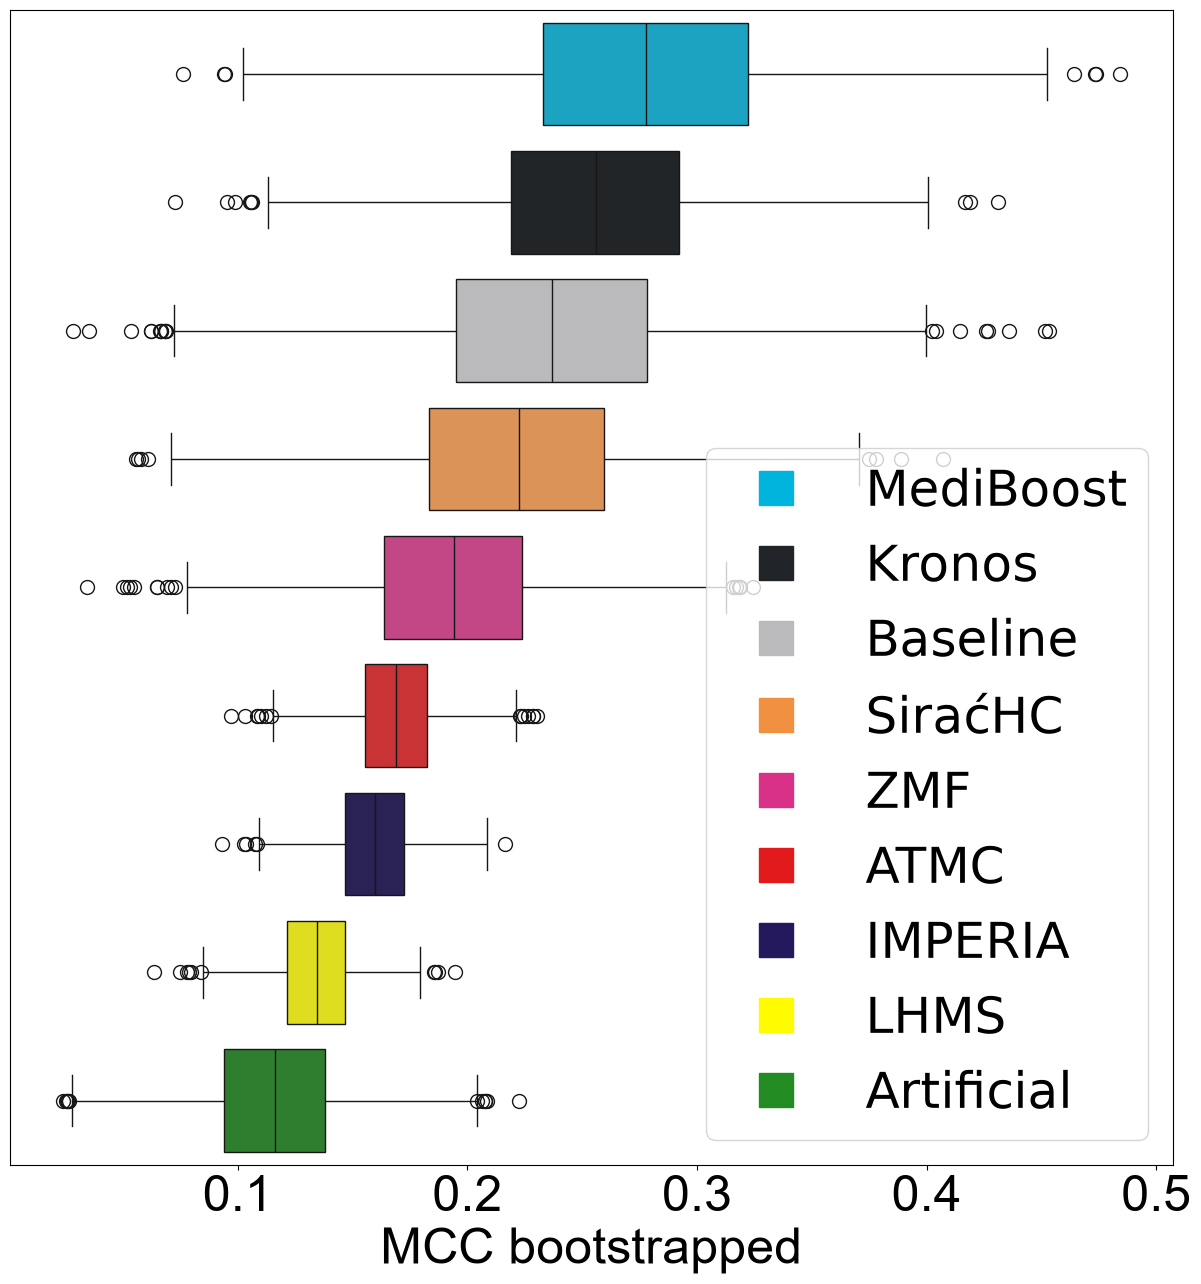

In [7]:
# Define the colors for each pair of columns
colors = []
ood_colors = []
for c in df_plot.columns:
    colors.append(c_map[c.split('_')[0]])
    ood_colors.append(c_map[c.split('_')[0]])
# box plots for dataframe df
plt.figure(figsize=(15,15))
sns.boxplot(data=df_plot, orient="h", palette=colors, fliersize=10)
plt.annotate("", xy=(-0.05, 0), xytext=(0, -0.05), arrowprops=dict(arrowstyle="->", lw=2, color='black'))
plt.annotate("", xy=(0, -0.05), xytext=(0.05, 0), arrowprops=dict(arrowstyle="->", lw=2, color='black'))

markers = [plt.Line2D([0,0],[0,0], color=c_map[c.split('_')[0]], marker='s', linestyle=''
                ) for  c in df_plot.columns ]
names = [c.split()[0] for c in df_plot.columns] 
plt.legend(markers, names, numpoints=1, 
        loc='lower right', fontsize=FONTSIZE, markerscale=MARKERSCALE)
plt.yticks([])
plt.xticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.xlabel('MCC bootstrapped', fontsize=FONTSIZE, fontname=FONTNAME)
title = 'phase_2_MCC_bootstrapped'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
# plt.xticks([])
plt.show()

## Out-of-distribution robustness comparison

The same bootstrap comparison is repeated for the out-of-distribution samples to assess how well each model generalizes to shifted data. This view is especially relevant for identifying models that remain stable under distributional drift.

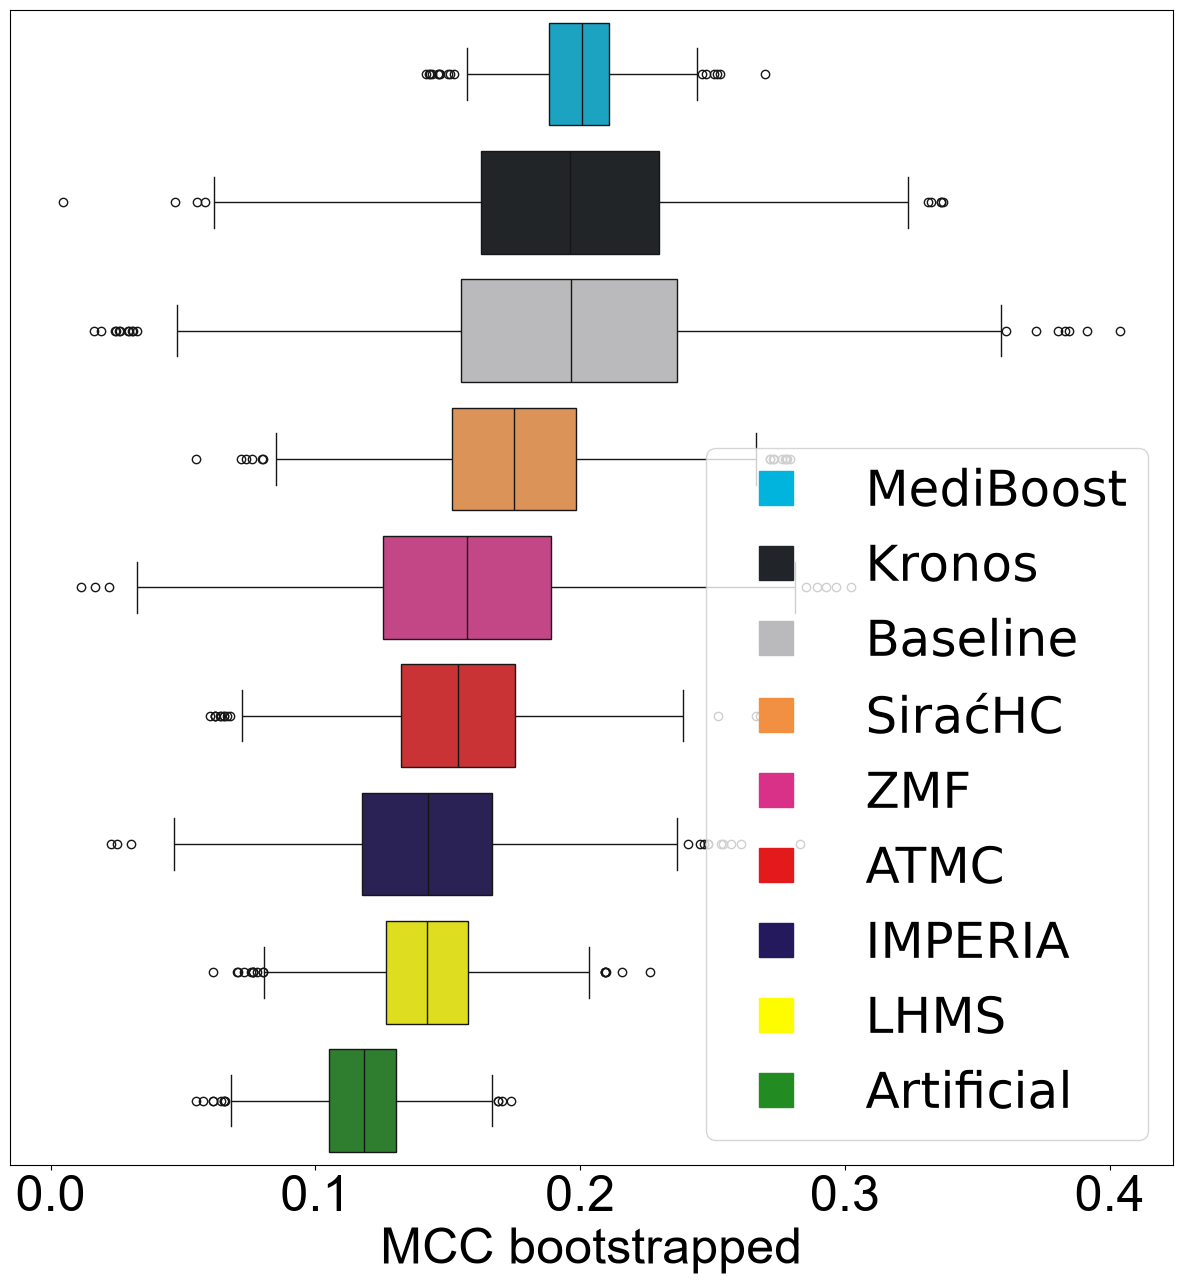

In [8]:
# box plots for dataframe df
palette = sns.color_palette(ood_colors, 9)
# box plots for dataframe df
plt.figure(figsize=(15,15))
sns.boxplot(data=df_ood_plot, orient="h", palette=palette)
markers = [plt.Line2D([0,0],[0,0], color=c_map[c.split('_')[0]], marker='s', linestyle=''
                ) for  c in df_plot.columns ]
names = [c.split()[0] for c in df_plot.columns] 
plt.legend(markers, names, numpoints=1, 
        loc='lower right', fontsize=FONTSIZE, markerscale=MARKERSCALE)
plt.legend(markers, names, numpoints=1, loc='lower right',
        fontsize=FONTSIZE, markerscale=MARKERSCALE)
plt.yticks([])
# show less x ticks
plt.xticks([0, 0.1, 0.2, 0.3, 0.4], fontsize=FONTSIZE, fontname=FONTNAME)
plt.xlabel('MCC bootstrapped', fontsize=FONTSIZE, fontname=FONTNAME)
title = 'phase_2_MCC_bootstrapped_ood'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

## ROC AUC and precision-recall analysis

This section compares team submissions using threshold-independent and ranking-based evaluation metrics on both in-distribution and out-of-distribution data. The plots provide a more complete view of model quality than a single classification threshold.

In [9]:
list_dir = os.listdir('task1_phase2')
top3 = ['MediBoost', 'SiraćHC', 'ZMF', 'Kronos']
final_submissions = {}
for d in list_dir:
    if '.csv' in d and d.split('_')[0] in top3:
        pred = pd.read_csv(f'task1_phase2/{d}')
        pred_np = pred['Label'].values
        proba_np = pred['Probability_1'].values
        # print(proba_np.shape, pred_np.shape, len(model.ytest), len(model.yood_test))
        ypred = pred_np[-len(model.ytest):]
        ood_ypred = pred_np[:len(model.yood_test)]
        yproba = proba_np[-len(model.ytest):]
        ood_yproba = proba_np[:len(model.yood_test)]
        num_bootstraps_BBC_CV = 2000
        mean_performance_bias_BBC_CV = 0
        final_submissions[d.split('_')[0]] = {
            'yproba': yproba, 'ood_yproba': ood_yproba,
        }
y_test = model.ytest.values
y_test_ood = model.yood_test.values

## In-distribution ROC AUC curves

The ROC curves show how well each selected team separates positive and negative cases on the in-distribution test data. Higher curves and larger AUC values indicate stronger classification performance under the standard evaluation setting.

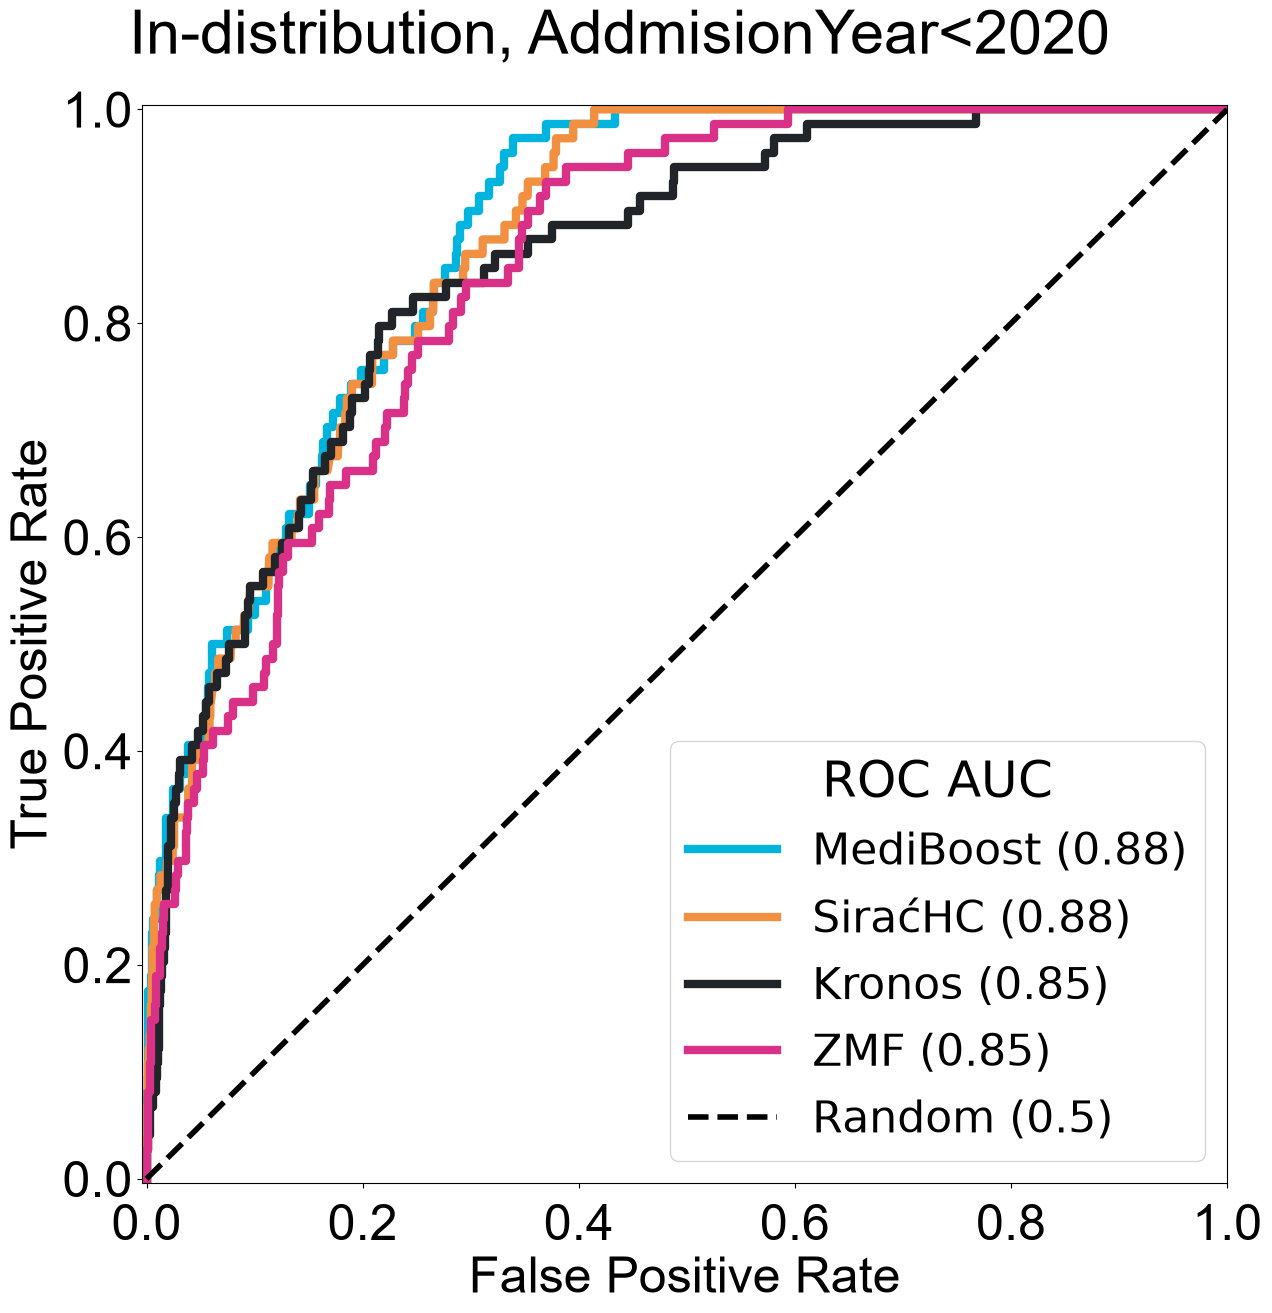

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt

plt.figure(figsize=FIGSIZE)
roc_aucs = []
for team, submission in final_submissions.items():
    roc_auc = roc_auc_score(y_test, submission['yproba'])
    roc_aucs.append(roc_auc)

sorted_teams = [x for _, x in sorted(zip(roc_aucs, final_submissions.keys()), reverse=True)]
    
for team in sorted_teams:
    submission = final_submissions[team]
    fpr, tpr, _ = roc_curve(y_test, submission['yproba'])
    roc_auc = roc_auc_score(y_test, submission['yproba'])
    plt.plot(fpr, tpr, label=f'{team} ({roc_auc:.2f})', color=c_map[team], linewidth=6)

plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)', linewidth=4, color='black')
plt.xlabel('False Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.ylabel('True Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.title('In-distribution, AddmisionYear<2020', fontsize = FONTSIZE+8, fontname=FONTNAME, y=1.04, x=0.44)
xx=0.02
yy=0.34
plt.legend(loc='lower right', fontsize=FONTSIZE-4, markerscale=MARKERSCALE+10,
           title='ROC AUC', title_fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE, y=-0.01, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, y=-0.01, fontname=FONTNAME)
plt.xlim(-0.004, 1)
plt.ylim(-0.004, 1.004)
title = 'phase_2_roc_auc_iid'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

## Out-of-distribution ROC AUC curves

These ROC curves evaluate whether the selected models maintain discriminative power when tested on later years with a shifted distribution. This is a key check for robustness and generalization in the Phase 2 challenge setting.

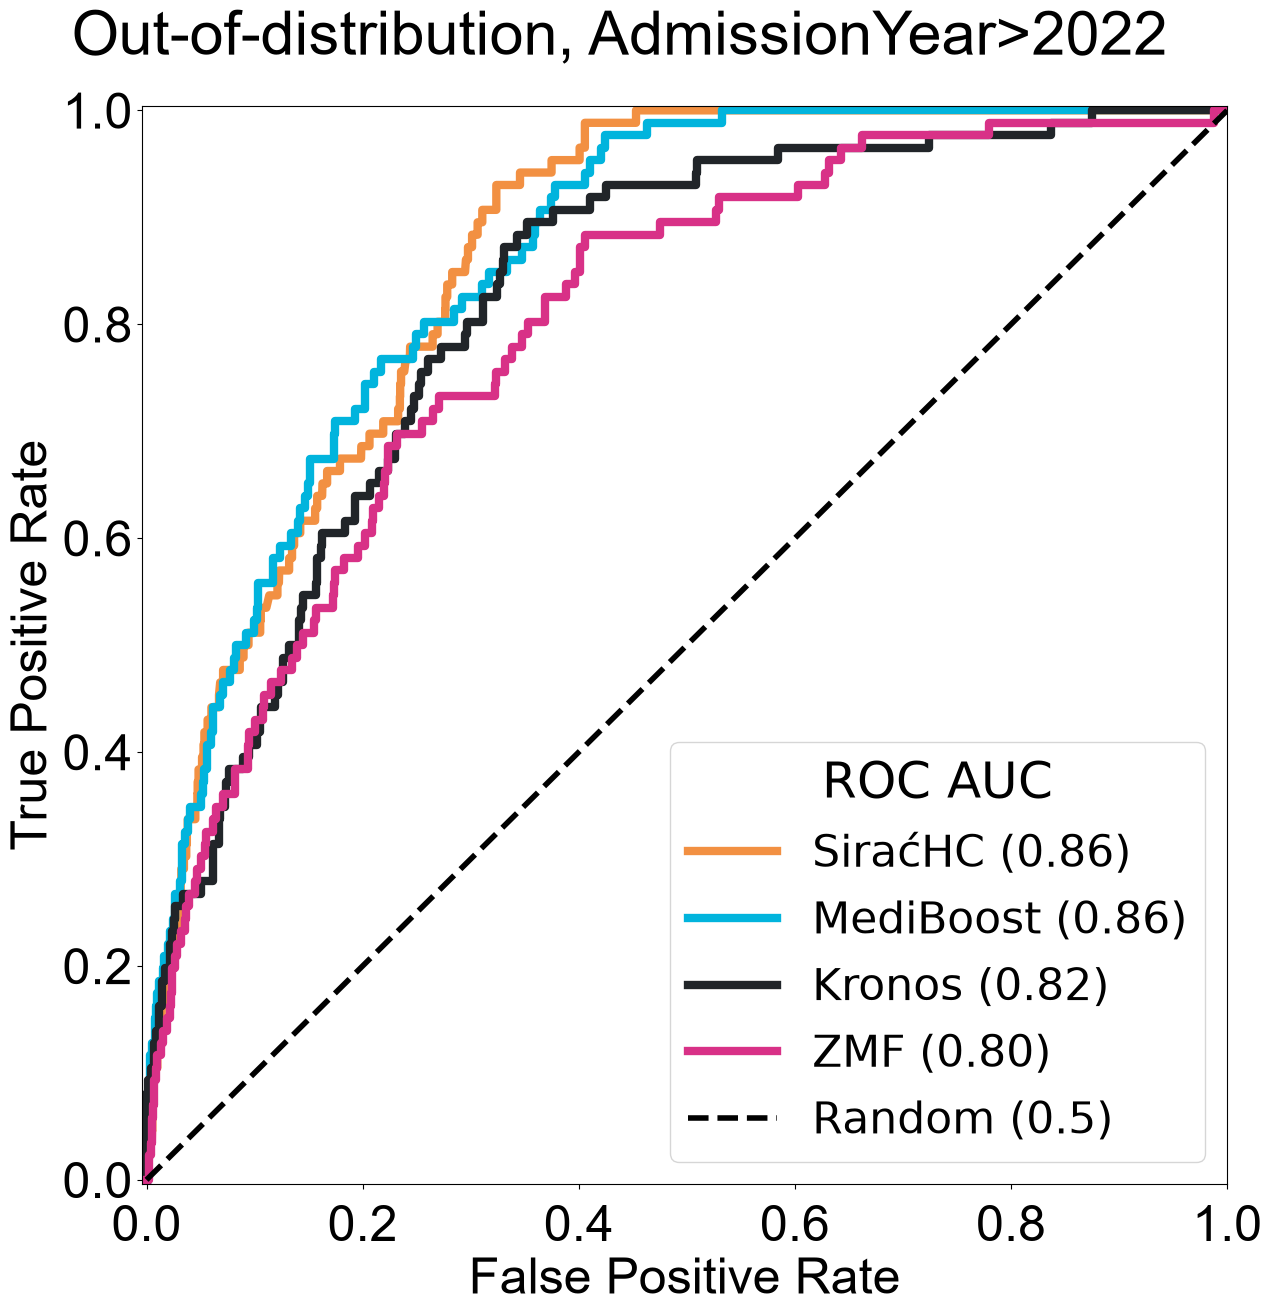

In [11]:
plt.figure(figsize=FIGSIZE)
roc_aucs = []
for team, submission in final_submissions.items():
    roc_auc = roc_auc_score(y_test_ood, submission['ood_yproba'])
    roc_aucs.append(roc_auc)

sorted_teams = [x for _, x in sorted(zip(roc_aucs, final_submissions.keys()), reverse=True)]
    
for team in sorted_teams:
    submission = final_submissions[team]
    fpr, tpr, _ = roc_curve(y_test_ood, submission['ood_yproba'])
    roc_auc = roc_auc_score(y_test_ood, submission['ood_yproba'])
    plt.plot(fpr, tpr, label=f'{team} ({roc_auc:.2f})', color=c_map[team], linewidth=6)

plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)', linewidth=4, color='black')
plt.xlabel('False Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.ylabel('True Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.title('Out-of-distribution, AdmissionYear>2022', fontsize = FONTSIZE+8, fontname=FONTNAME, y=1.04, x=0.44)
plt.legend(loc='lower right', fontsize=FONTSIZE-4, markerscale=MARKERSCALE+10,
           title='ROC AUC', title_fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE, y=-0.01, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, y=-0.01, fontname=FONTNAME)
plt.xlim(-0.004, 1)
plt.ylim(-0.004, 1.004)
title = 'phase_2_roc_auc_ood'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

## In-distribution precision-recall curves

The precision-recall curves summarize the trade-off between precision and recall for each model on the in-distribution data. This is particularly informative when class imbalance makes overall accuracy less meaningful.

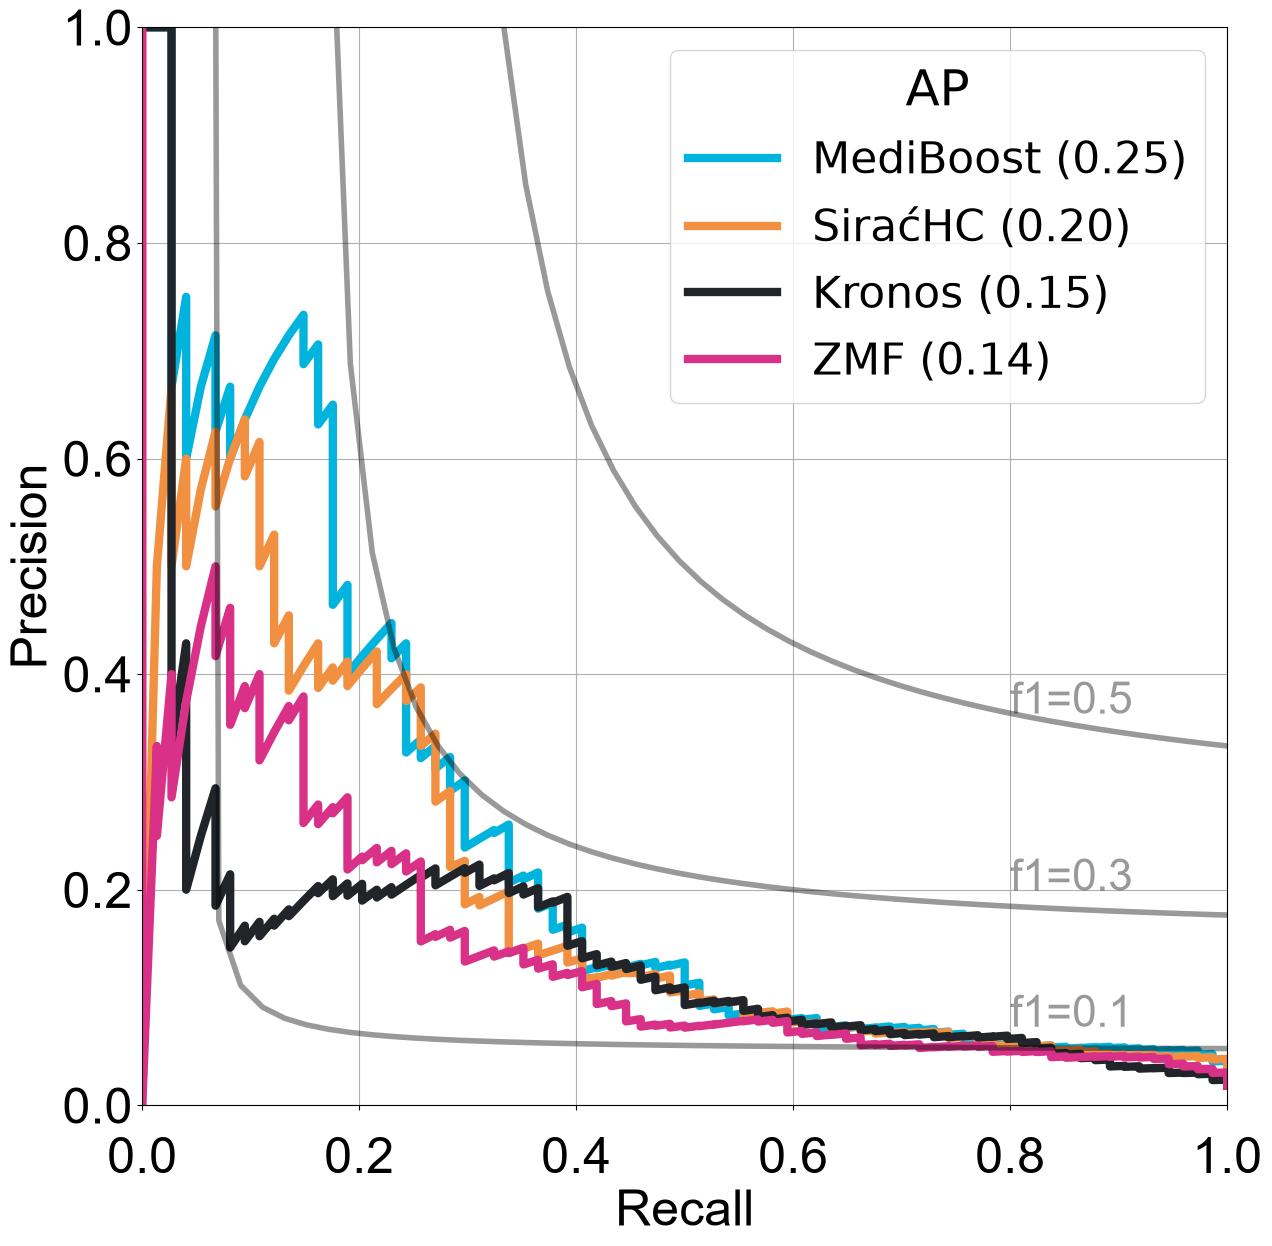

In [12]:
plt.figure(figsize=(14, 14))
mAP = []
for team, submission in final_submissions.items():
    average_precision = average_precision_score(y_test,submission['yproba'])
    mAP.append(average_precision.mean())

sorted_teams = [x for _, x in sorted(zip(mAP, final_submissions.keys()), reverse=True)]
    
for team in sorted_teams:
    submission = final_submissions[team]
    try:
        precision, recall, _ = precision_recall_curve(y_test, submission['yproba'])
        average_precision = average_precision_score(y_test, submission['yproba'])

        mAP = average_precision.mean()
        plt.plot(recall, precision, color=c_map[team], label=f'{team} ({mAP:.2f})', linewidth=6)
        # plt.plot(recall, precision, label=team, linewidth=4)
    except:
        print(f"Error with {team}")
f_scores = np.linspace(0.1, 0.5, num=3)
lines, labels = [], []
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    (l,) = plt.plot(x[y >= 0], y[y >= 0], color="black", alpha=0.4, linewidth=4)
    plt.annotate("f1={0:0.1f}".format(f_score), xy=(0.8, y[45] + 0.02), fontsize=FONTSIZE-4, 
                color='black', alpha=0.4, fontname=FONTNAME)
xx=0.338
yy=0.258
# plt.axvline(x=xx, color=cmap['irb-blue'], linestyle='--', linewidth=4)
# plt.annotate('Recall = {:.2f}'.format(xx), xy=(xx, yy), xytext=(xx+0.07, yy+0.04),
#     arrowprops=dict(facecolor='black', arrowstyle='->', lw = 4, color=cmap['irb-blue']),
#     fontsize=FONTSIZE-4, color=cmap['irb-blue'], fontname=FONTNAME)

# plt.axhline(y=yy, color=cmap['Challengers'], linestyle='--', linewidth=4)
# plt.annotate('Precision = {:.2f}'.format(yy), xy=(xx, yy), xytext=(xx+0.1, yy-0.105), 
#     arrowprops=dict(facecolor='black', arrowstyle='->', color=cmap['Challengers'],lw=4),
#     fontsize=FONTSIZE-4, color=cmap['Challengers'], fontname=FONTNAME) 


plt.xlabel('Recall', fontsize=FONTSIZE, fontname=FONTNAME)
plt.ylabel('Precision', fontsize=FONTSIZE, fontname=FONTNAME)
plt.legend(loc='upper right', fontsize=FONTSIZE-4,
        title='AP', title_fontsize=FONTSIZE)

plt.xticks(fontsize=FONTSIZE, y=-0.02, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
title = 'phase_2_pr_iid'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

## Out-of-distribution precision-recall curves

This figure evaluates the same precision-recall trade-off under out-of-distribution conditions. It reveals whether the top-performing methods remain reliable when the data distribution changes over time.

Kronos [0.09779207 0.58833057 0.62712836 ... 0.08450384 0.08227468 0.18445282]
MediBoost [0.0021739  0.14243338 0.06963491 ... 0.00198651 0.00174282 0.01131083]
SiraćHC [0.03137058 0.67115957 0.65009731 ... 0.00734405 0.00644632 0.2020864 ]
ZMF [0.23749208 0.9646776  0.8753331  ... 0.02569486 0.11708743 0.1146901 ]


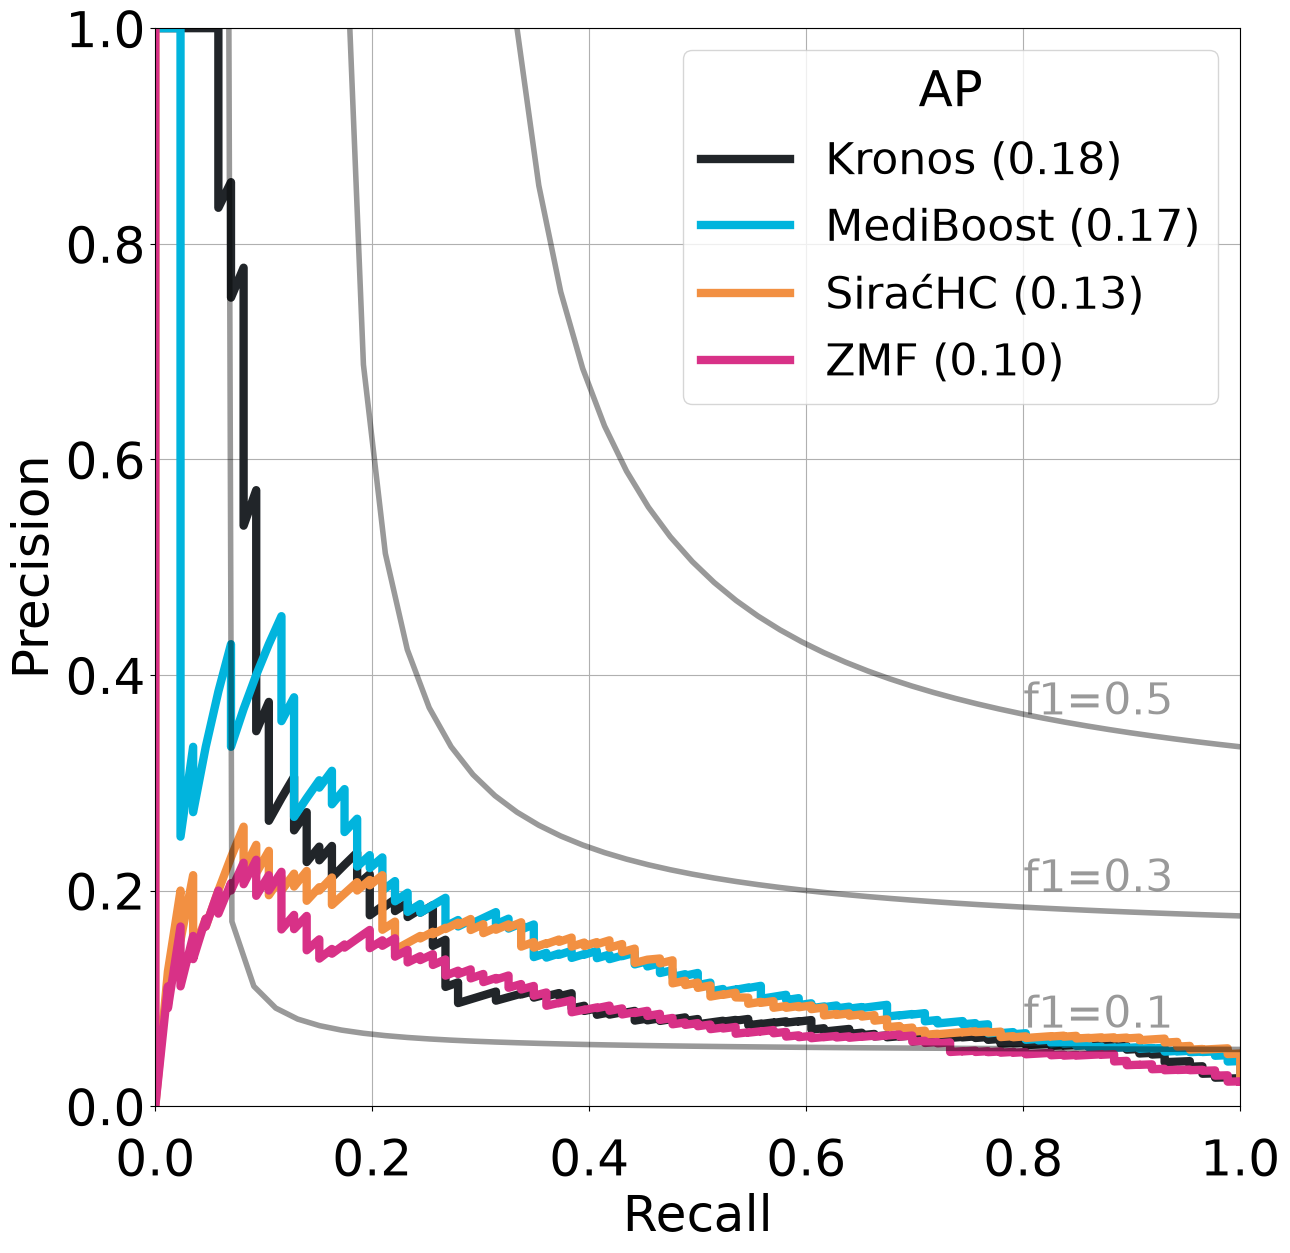

In [13]:
plt.figure(figsize=(14, 14))
mAP = []
for team, submission in final_submissions.items():
    average_precision = average_precision_score(y_test_ood,submission['ood_yproba'])
    mAP.append(average_precision.mean())

sorted_teams = [x for _, x in sorted(zip(mAP, final_submissions.keys()), reverse=True)]
    
for team in sorted_teams:
    submission = final_submissions[team]
    print(team, submission['ood_yproba'])
    precision, recall, _ = precision_recall_curve(y_test_ood, submission['ood_yproba'])
    average_precision = average_precision_score(y_test_ood, submission['ood_yproba'])
    mAP = average_precision.mean()
    plt.plot(recall, precision, color=c_map[team], label=f'{team} ({mAP:.2f})', 
            linewidth=6)
    
    # plt.plot(recall, precision, label=team, linewidth=4)
f_scores = np.linspace(0.1, 0.5, num=3)
lines, labels = [], []
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    (l,) = plt.plot(x[y >= 0], y[y >= 0], color="black", alpha=0.4, linewidth=4)
    plt.annotate("f1={0:0.1f}".format(f_score), xy=(0.8, y[45] + 0.02), 
                fontsize=FONTSIZE-4, color='black', alpha=0.4)
    
plt.xlabel('Recall', fontsize=FONTSIZE)
plt.ylabel('Precision', fontsize=FONTSIZE)
plt.title('', fontsize = FONTSIZE+4, y=1.04)
plt.legend(loc='upper right', fontsize=FONTSIZE-4, title='AP', title_fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE, y=-0.02)
plt.yticks(fontsize=FONTSIZE)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
title = 'phase_2_pr_ood'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

## Metrics private calculate swarm plot and H_measure vs MCC


In [14]:
import matplotlib.pyplot as plt

# plot them side by side with same y axis values
def plot_image(samp_perf_list, ood_samp_perf_list, conf_int, ood_conf_int, name):
    plt.figure(figsize=(6, 6))
    plt.hist(samp_perf_list, bins=20, color='blue', alpha=0.5, label='In-distribution')
    plt.hist(ood_samp_perf_list, bins=20, color='red', alpha=0.5, label='OOD')
    plt.xlabel('Performance')
    plt.ylabel('Frequency')
    plt.title('Sampled test set evaluations team: {}, MCC:{:.3f}'.format(
        name, 0.75*np.mean(samp_perf_list) + 0.25*np.mean(ood_samp_perf_list)), fontsize=FONTSIZE)    
    # highlight mean of each distribution
    plt.axvline(np.mean(samp_perf_list), color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(np.mean(ood_samp_perf_list), color='red', linestyle='dashed', linewidth=1)
    # text on the mean lines
    plt.text(np.mean(samp_perf_list), 100, 'Mean: {:.4f}'.format(np.mean(samp_perf_list)), rotation=45)
    plt.text(np.mean(ood_samp_perf_list), 100, 'Mean: {:.4f}'.format(np.mean(ood_samp_perf_list)), rotation=45)
    # show 95% confidence intervals 25% lenght of the full vertical axis
    plt.axvline(conf_int[0], ymax=0.25, color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(conf_int[-1], ymax=0.25, color='blue', linestyle='dashed', linewidth=1)
    plt.axvline(ood_conf_int[0], ymax=0.25, color='red', linestyle='dashed', linewidth=1)
    plt.axvline(ood_conf_int[-1], ymax=0.25, color='red', linestyle='dashed', linewidth=1)
    plt.legend()
    plt.show()


## Sampling distribution diagnostics

This section visualizes the distribution of bootstrapped performance values for each team across in-distribution and OOD samples. The histograms help interpret the stability of the model estimates and the overlap between evaluation regimes.

In [15]:
def make_distribution_image(model, yhat, yoodhat, name):
    num_bootstraps_BBC_CV = 2000
    mean_performance_bias_BBC_CV = 0
    predictions = yhat
    ood_predictions = yoodhat

    print("In-distribution")
    performance_BBC_CV, samp_perf_list = BBC_CV(
            len(predictions), predictions, num_bootstraps_BBC_CV,
                            model.ytest.values)
    print("OOD")
    ood_performance_BBC_CV, ood_samp_perf_list = BBC_CV(
            len(ood_predictions), ood_predictions, num_bootstraps_BBC_CV, 
                model.yood_test.values)
    mcc = 0.75*samp_perf_list + 0.25*ood_samp_perf_list
    print(mcc.shape)
    print("MediBoost MCC: {}".format(np.mean(np.percentile(mcc, [2.5, 97.5]))))
    conf_int = np.percentile(samp_perf_list, [2.5, 97.5])
    ood_conf_int = np.percentile(ood_samp_perf_list, [2.5, 97.5])
    
    plot_image(samp_perf_list, ood_samp_perf_list, conf_int, ood_conf_int, name)
    
# make_distribution_image(model, mbyhat, ood_mbyhat, 'MediBoost')

In [ ]:
teams = ['MediBoost', 'ZMF', 'SiraćHC', 'Kronos']
files = ['MediBoost_6_20241204.csv','ZMF_9_20240412.csv', 'SiraćHC_6_20240412.csv', 'Kronos_4_12-04-2024.csv']
for t, f in zip(teams, files):
    team = pd.read_csv(f'Task1AllTeamsPhase2\{t}_Final\Task1prediktivni\{f}')
    team_np = team['Label'].values
    yhat = team_np[-len(model.ytest):]
    ood_yhat = team_np[:len(model.yood_test)]
    print(yhat.shape, ood_yhat.shape)
    print(f"Team: {t}")
    make_distribution_image(model, yhat, ood_yhat, t)